In [2]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
import tqdm
import matplotlib.pyplot as plt

import cmasher as cmr
import numpy as np
import pickle
from scipy.stats import pearsonr

from utils.misc.results_saving import save_results, load_results, load_results_for_model_and_revisions, load_all_results
from utils.model_definitions.text_automodel_wrapper import TextModelSpecifications

plt.rcParams.update({'font.size': 14})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
all_results = load_all_results(should_normalize_scores_across_models=False, base_path='results')

# Single Model, Average Metric vs Average Main Score for each layer

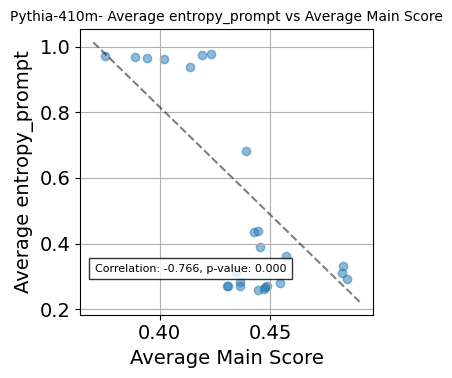

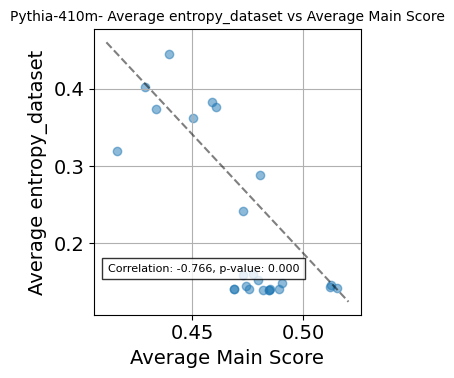

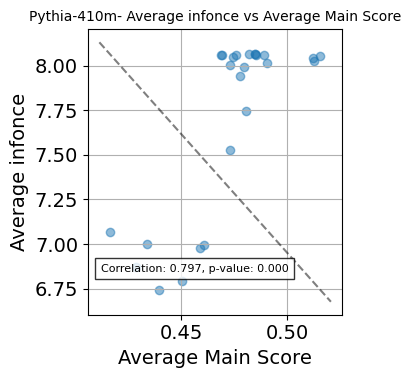

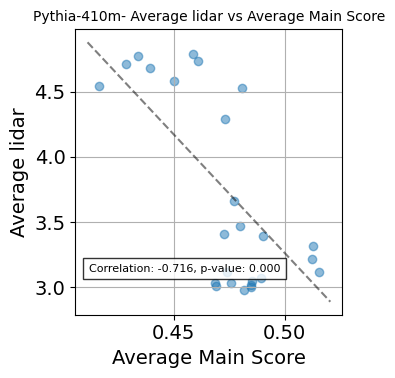

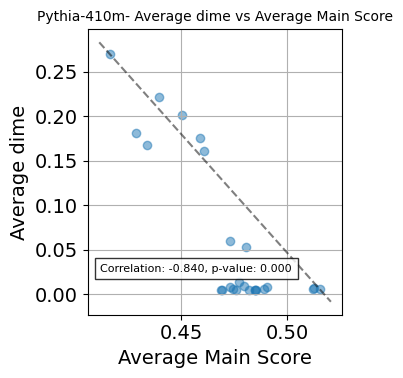

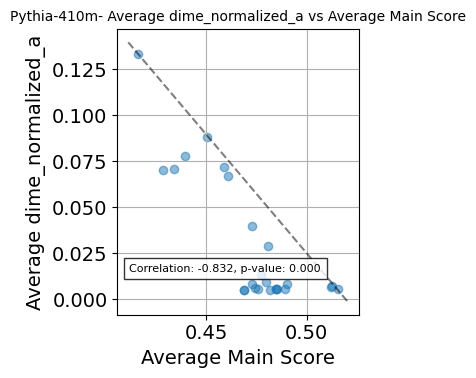

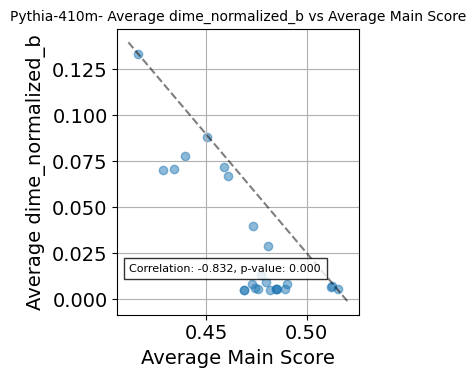

In [7]:
METRICS_CHOICES = ['entropy_prompt', 
           'entropy_dataset',
           'infonce',
           'lidar',
           'dime',
           'dime_normalized_a',
           'dime_normalized_b']

model_specs = TextModelSpecifications(
    model_family='Pythia',
    model_size='410m',
    revision='main'
)

for METRIC_TO_PLOT in METRICS_CHOICES:
    x_values = []  # Main scores
    y_values = []  # Entropy values
    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
            
        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        
        # Calculate average main score for this layer
        main_scores = []
        metric_values = []
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])
                
                if METRIC_TO_PLOT == 'entropy_prompt':
                    metric_values.append(task_results['entropy_prompt']['maxEntropy'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD'] / task_results['entropy_dataset']['logD'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_dataset']['raw'])

            except KeyError as e:
                #print(f"KeyError for task {task_name} in layer {layer}", e)
                main_scores.remove(main_scores[-1])
                continue
                
        if main_scores:
            x_values.append(np.mean(main_scores))
            y_values.append(np.mean(metric_values))

    # Create square scatter plot
    plt.figure(figsize=(4, 4))
    plt.scatter(x_values, y_values, alpha=0.5)
    plt.xlabel('Average Main Score')
    plt.ylabel(f'Average {METRIC_TO_PLOT}')
    plt.title(f'{model_specs.model_family}-{model_specs.model_size}- Average {METRIC_TO_PLOT} vs Average Main Score', fontsize=10)
    plt.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(x_values, y_values)
    plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}, p-value: {p_value:.3f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8), fontsize=8)

    # Add negative diagonal line
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Single Layer, Metric vs Main Score for each task

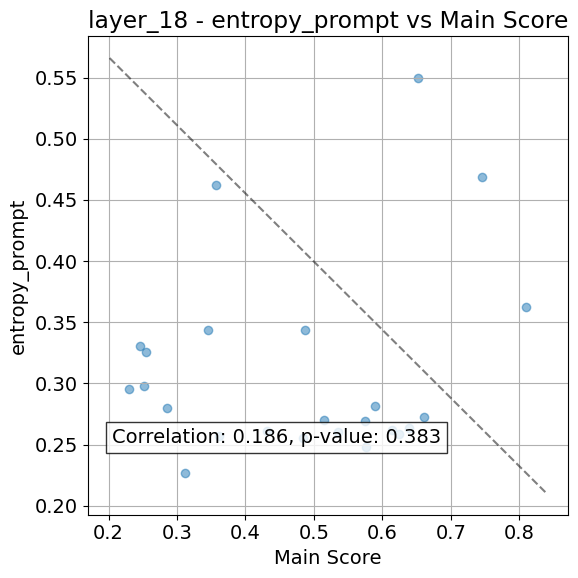

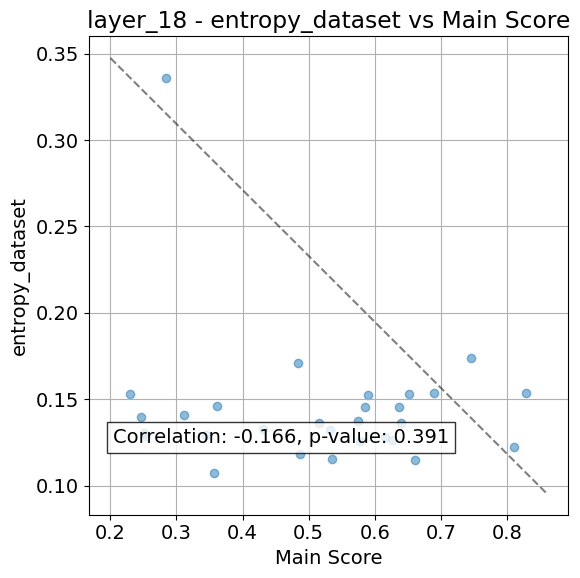

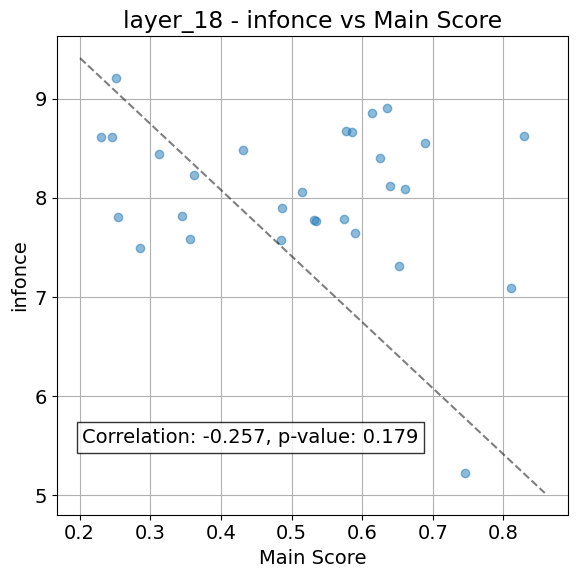

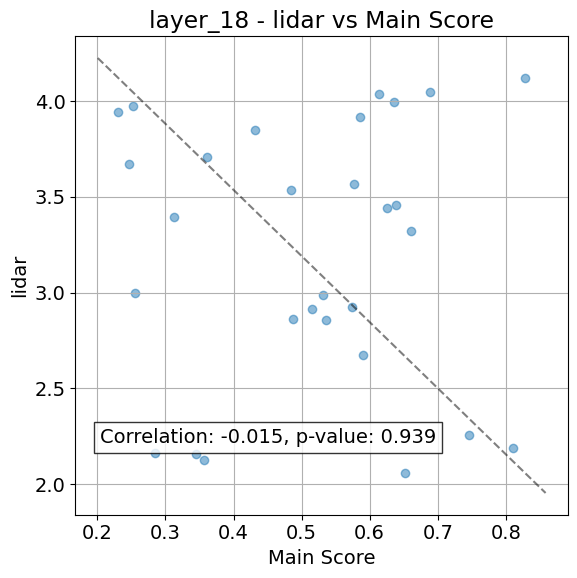

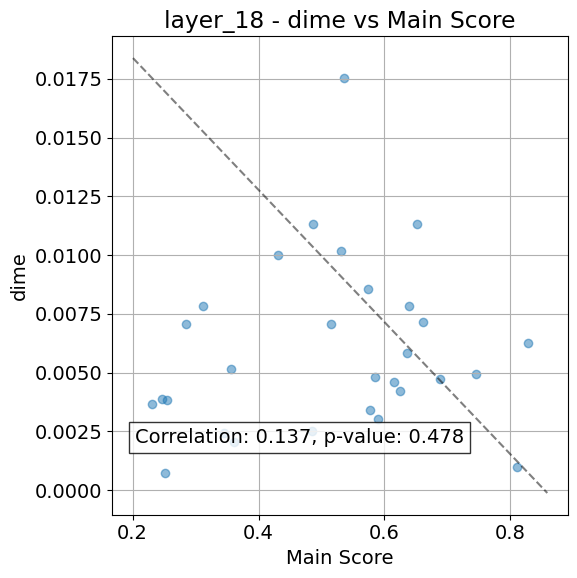

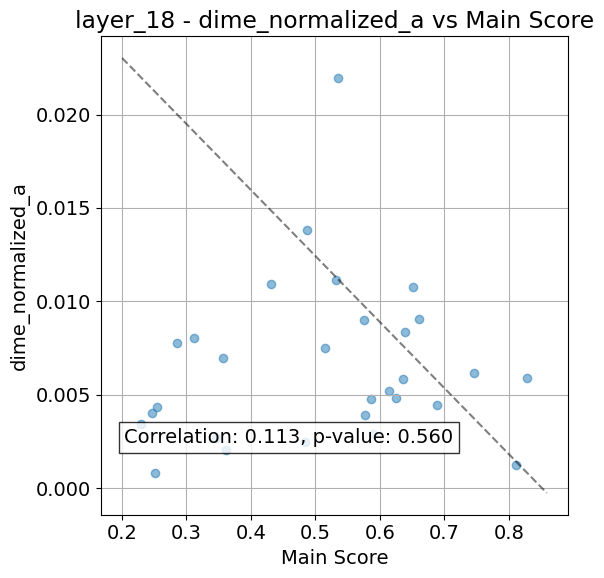

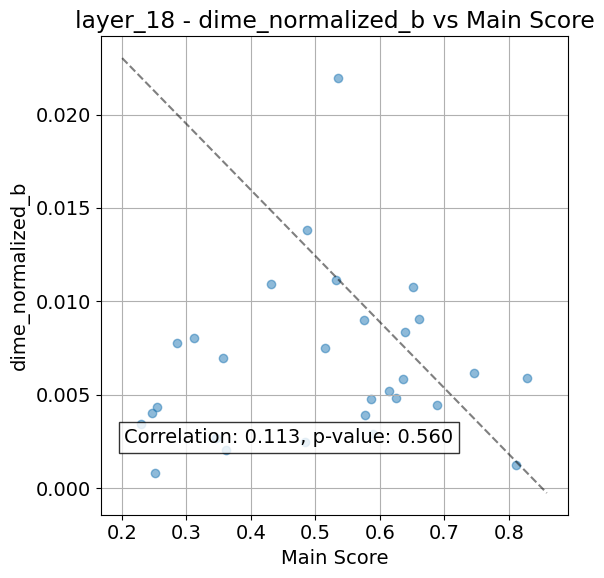

In [8]:
METRICS_CHOICES = ['entropy_prompt', 
           'entropy_dataset',
           'infonce',
           'lidar',
           'dime',
           'dime_normalized_a',
           'dime_normalized_b']
LAYER_TO_PLOT = 'layer_18'

model_specs = TextModelSpecifications(
    model_family='Pythia',
    model_size='410m',
    revision='main'
)

for METRIC_TO_PLOT in METRICS_CHOICES:
    main_scores = []
    metric_values = []

    for layer in all_results[model_specs.model_family][model_specs.model_size]['main'].keys():
        if not layer.startswith('layer_'):
            continue
        if layer != LAYER_TO_PLOT:
            continue
            
        layer_results = all_results[model_specs.model_family][model_specs.model_size]['main'][layer]
        for task_name, task_results in layer_results.items():
            try:
                main_scores.append(task_results['main_score'])
                
                if METRIC_TO_PLOT == 'entropy_prompt':
                    metric_values.append(task_results['entropy_prompt']['maxEntropy'])
                elif METRIC_TO_PLOT == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif METRIC_TO_PLOT == 'infonce':
                    metric_values.append(task_results['infonce']['raw'])
                elif METRIC_TO_PLOT == 'lidar':
                    metric_values.append(task_results['lidar']['raw'])
                elif METRIC_TO_PLOT == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif METRIC_TO_PLOT == 'dime_normalized_a':
                    metric_values.append(task_results['dime']['logD'] / task_results['entropy_dataset']['logD'])
                elif METRIC_TO_PLOT == 'dime_normalized_b':
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_dataset']['raw'])

            except KeyError as e:
                #print(f"KeyError for task {task_name} in layer {layer}", e)
                main_scores.remove(main_scores[-1])
                continue

    # Create square scatter plot
    plt.figure(figsize=(6, 6))
    plt.scatter(main_scores, metric_values, alpha=0.5)
    plt.xlabel('Main Score')
    plt.ylabel(f'{METRIC_TO_PLOT}')
    plt.title(f'{LAYER_TO_PLOT} - {METRIC_TO_PLOT} vs Main Score')
    plt.grid(True)

    # Calculate and display correlation coefficient
    correlation, p_value = pearsonr(main_scores, metric_values)
    plt.text(0.05, 0.15, f'Correlation: {correlation:.3f}, p-value: {p_value:.3f}', 
             transform=plt.gca().transAxes, 
             bbox=dict(facecolor='white', alpha=0.8))

    # Add negative diagonal line
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    plt.plot([x_min, x_max], [y_max, y_min], 'k--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Main Score Across Layers

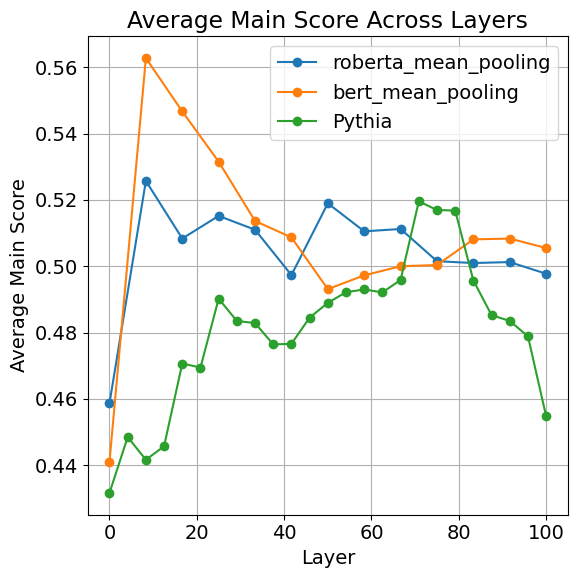

In [13]:
# plot roberta base main score across layers

specs_list = [
    TextModelSpecifications(
        model_family='roberta_mean_pooling',
        model_size='base',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='bert_mean_pooling',
        model_size='base',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='Pythia',
        model_size='410m',
        revision='main',
        ignore_checks=True
    )
]

plt.figure(figsize=(6, 6))

for specs in specs_list:    
    average_main_scores = []
    layer_nums = []
    
    for layer in all_results[specs.model_family][specs.model_size]['main'].keys():
        if not layer.startswith('layer_') or '_last' in layer:
            continue
            
        layer_num = int(layer.split('_')[1])
        layer_nums.append(layer_num)
        
        layer_results = all_results[specs.model_family][specs.model_size]['main'][layer]
        main_scores = []

        for task_name, task_results in layer_results.items():
            main_scores.append(task_results['main_score'])

        average_main_scores.append(np.mean(main_scores))

    # Sort by layer number
    sorted_indices = np.argsort(layer_nums)
    layer_nums = np.array(layer_nums)[sorted_indices]
    depth_percentages = np.linspace(0, 100, len(layer_nums))
    average_main_scores = np.array(average_main_scores)[sorted_indices]
    
    plt.plot(depth_percentages, average_main_scores, marker='o', label=specs.model_family)

plt.xlabel('Layer')
plt.ylabel('Average Main Score')
plt.title('Average Main Score Across Layers')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


## Metric Across Layers

In [4]:
all_results = load_all_results(should_normalize_scores_across_models=False, base_path='newresults')

newresults/bert/large/main/metrics/mteb
newresults/bert/base/main/metrics/mteb
newresults/roberta/large/main/metrics/mteb
newresults/roberta/base/main/metrics/mteb
newresults/Pythia/160m/main/metrics/mteb
newresults/Pythia/70m/main/metrics/mteb
newresults/Pythia/14m/main/metrics/mteb
newresults/Pythia/1b/main/metrics/mteb
newresults/Pythia/410m/main/metrics/mteb
newresults/LLM2Vec-mntp/8B/main/metrics/mteb
newresults/mamba/370m/main/metrics/mteb


/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/AD/ofsk222/miniconda3/envs/information_plane/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [70]:
# print average main score for every BERT layer
for layer in all_results['bert']['base']['main'].keys():
    if not layer.startswith('layer_'):
        continue
    print(f"Layer {layer}: {all_results['bert']['base']['main'][layer]['average_main_score']}")


Layer layer_0: nan
Layer layer_1: 0.2901421696269611
Layer layer_2: 0.3216392433628507
Layer layer_3: 0.31147361241837684
Layer layer_4: 0.3804232601683104
Layer layer_5: 0.3963744257740436
Layer layer_6: 0.3573692078017606
Layer layer_7: 0.3323792279069417
Layer layer_8: 0.3180061893014217
Layer layer_9: 0.3150756723133216
Layer layer_10: 0.32720598847279964
Layer layer_11: 0.35453583583325415
Layer layer_12: 0.5141909783119376


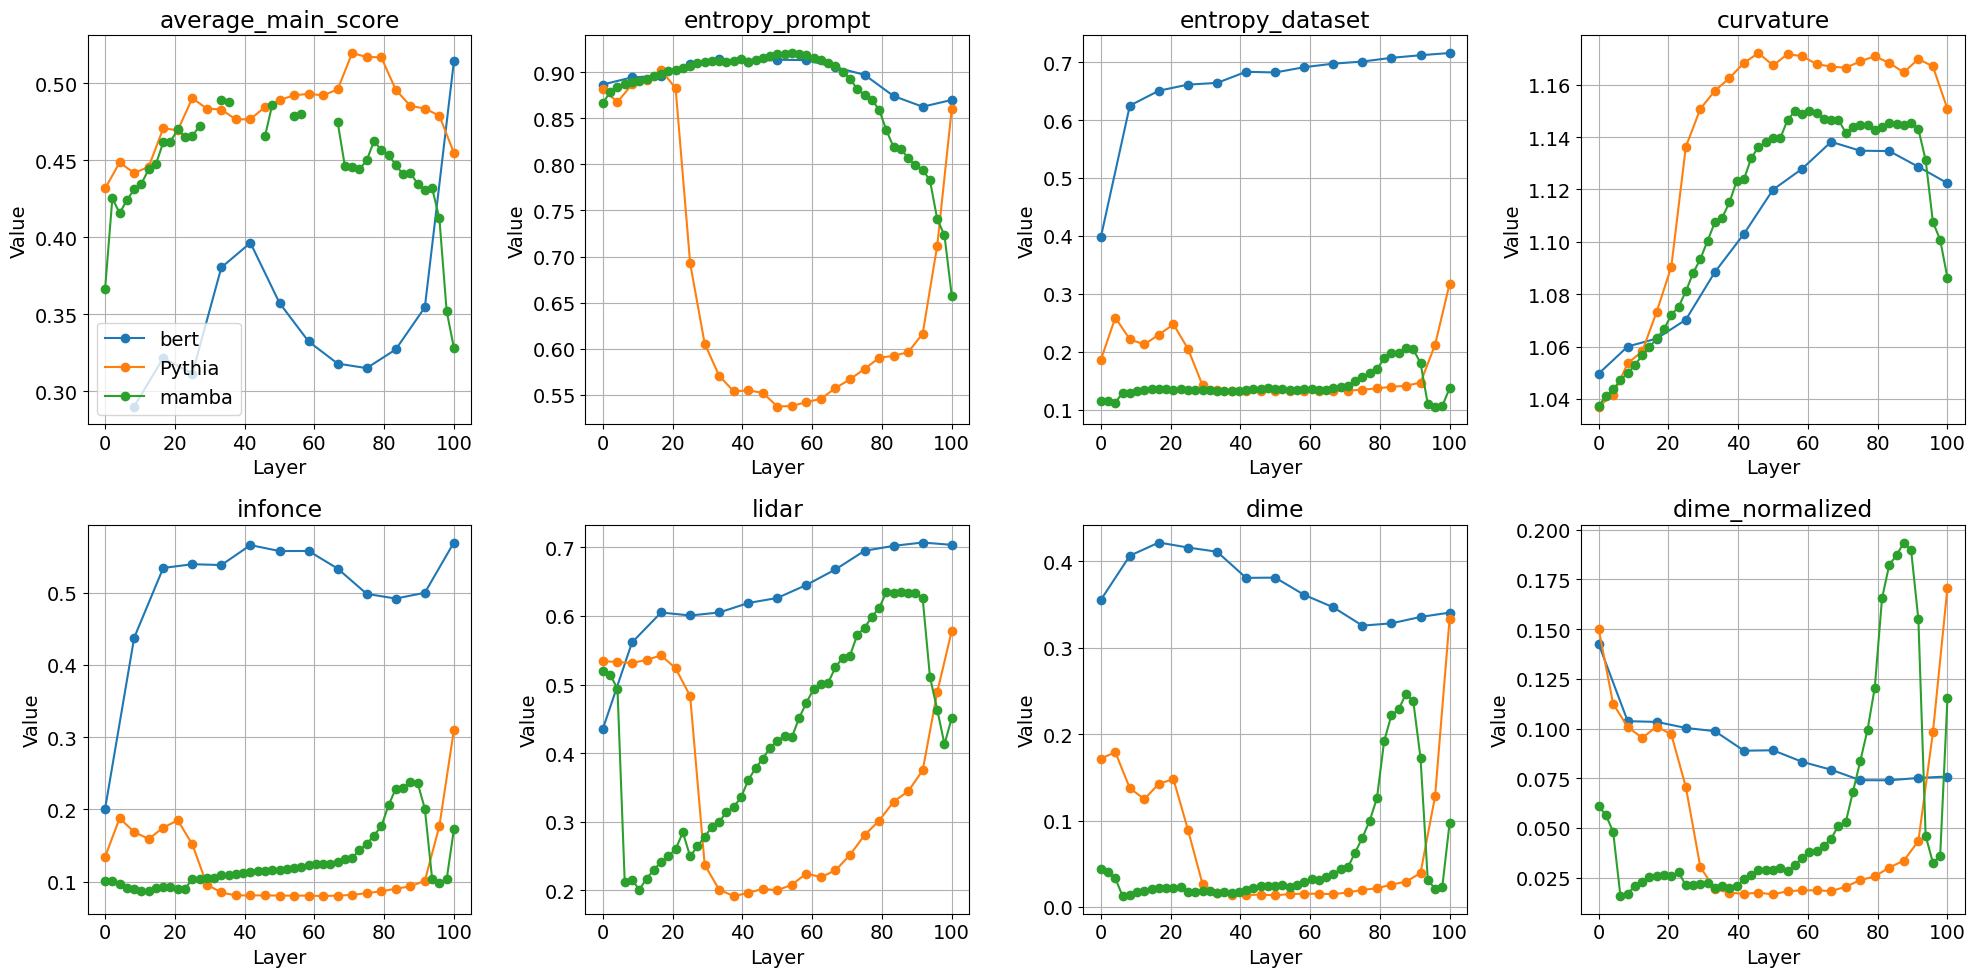

In [5]:
# plot metrics across layers

specs_list = [
    TextModelSpecifications(
        model_family='bert',
        model_size='base',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='Pythia',
        model_size='410m',
        revision='main',
        ignore_checks=True
    ),
    TextModelSpecifications(
        model_family='mamba',
        model_size='370m',
        revision='main',
        ignore_checks=True
    ),
]

metrics = ['average_main_score', 'entropy_prompt', 'entropy_dataset', 'curvature', 'infonce', 'lidar', 'dime', 'dime_normalized']
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for metric_idx, metric in enumerate(metrics):
    ax = axes[metric_idx]
    
    for specs in specs_list:    
        model_metric_values = []
        layer_nums = []
        
        for layer in all_results[specs.model_family][specs.model_size]['main'].keys():
            if not layer.startswith('layer_') or '_last' in layer:
                continue
                
            layer_num = int(layer.split('_')[1])
            layer_nums.append(layer_num)
            
            layer_results = all_results[specs.model_family][specs.model_size]['main'][layer]
            metric_values = []

            for task_name, task_results in layer_results.items():
                if task_name != 'wikitext' and task_name != 'average_main_score':
                    continue
                if metric != 'dime_normalized' and isinstance(task_results, dict) and metric not in task_results:
                    continue
                if task_name == 'average_main_score' and metric != 'average_main_score':
                    continue
                if metric == 'average_main_score':
                    # TEMP: for missing mamba tasks
                    if specs.model_family == 'mamba' and task_results > 0.6:
                        continue
                    metric_values.append(task_results)
                elif metric == 'entropy_prompt':
                    metric_values.append(task_results['entropy_prompt']['maxEntropy'])
                elif metric == 'entropy_dataset':
                    metric_values.append(task_results['entropy_dataset']['maxEntropy'])
                elif metric == 'infonce':
                    dimensionalities = {
                        'bert': 768,
                        'roberta': 768,
                        'mamba': 1024,
                        'Pythia': 1024
                    }
                    upper_bound = np.log(dimensionalities[specs.model_family])
                    metric_values.append(1 - task_results['infonce']['raw'] / upper_bound)
                elif metric == 'lidar':
                    metric_values.append(task_results['lidar']['maxEntropy'])
                elif metric == 'dime':
                    metric_values.append(task_results['dime']['raw'])
                elif metric == 'dime_normalized':
                    if 'entropy_dataset' not in task_results:
                        continue
                    metric_values.append(task_results['dime']['raw'] / task_results['entropy_dataset']['raw'])
                elif metric == 'average_main_score':
                    metric_values.append(task_results['main_score'])
                elif metric == 'curvature':
                    metric_values.append(task_results['curvature']['raw'])

            model_metric_values.append(np.mean(metric_values))
        
        depth_percentages = np.linspace(0, 100, len(model_metric_values))
        ax.plot(depth_percentages, model_metric_values, marker='o', label=specs.model_family)
        
    ax.set_xlabel('Layer')
    ax.set_ylabel('Value')
    ax.set_title(f'{metric}')
    ax.grid(True)

    if metric == 'average_main_score':
        ax.legend(loc='lower left')

# hide unused axes
for ax in axes:
    if ax.get_title() not in metrics:
        ax.set_visible(False)

plt.tight_layout()
plt.show()

# Image Models

In [ ]:
import os 

IMAGE_MODEL_NAMES = ['clip', 'beit', 'mae', 'dinov2']
MODEL_TO_SIZE = {
    'clip': 'large',
    'beit': 'base',
    'mae': 'base',
    'dinov2': 'base'
}
model_to_results = {}
for model_name in IMAGE_MODEL_NAMES:
    model_to_results[model_name] = {}
    path = f'results/{model_name}/{MODEL_TO_SIZE[model_name]}/main/metrics/imagenet/val'

    for result_pkl in os.listdir(path):
        with open(os.path.join(path, result_pkl), 'rb') as f:
            metric_name = result_pkl.split('.')[0]
            model_to_results[model_name][metric_name] = pickle.load(f)

    downstream_path

print(model_to_results)

{'clip': {'entropy_dataset': {'maxEntropy': [0.463699009306692, 0.5784480805407937, 0.6224177306602195, 0.6567652962182107, 0.6828881655539267, 0.6978588790332214, 0.715941499920032, 0.7353439341740262, 0.7501970675892072, 0.7584918476746029, 0.7648056904034937, 0.7780615650866077, 0.783307996690306, 0.7780997884887253, 0.7884097350040168, 0.8043226988099283, 0.8133317314377284, 0.8286803313660875, 0.8433444427726972, 0.8527985853523038, 0.8543670512795931, 0.8047847729671719, 0.7912889738873131, 0.8321940334203582, 0.8250839145079145], 'raw': [3.2031192793970886, 3.995777781972752, 4.299509364700214, 4.536773942003611, 4.7172243305595645, 4.820638355626292, 4.94554867551499, 5.079575943158122, 5.182177753916265, 5.2394760648391525, 5.283090545280311, 5.374658883600118, 5.410899949206383, 5.374922921507876, 5.446141508974905, 5.556064368709442, 5.61829656140265, 5.724320933582757, 5.825617026563347, 5.890923929875875, 5.9017585086650115, 5.559256263908422, 5.4660305865704455, 5.7485927

0 entropy_dataset clip
1 dime clip
2 entropy_prompt clip
3 lidar clip
4 infonce clip
5 dime_normalized clip
0 entropy_dataset beit
1 dime beit
2 entropy_prompt beit
3 lidar beit
4 infonce beit
5 dime_normalized beit
0 entropy_dataset mae
1 dime mae
2 entropy_prompt mae
3 lidar mae
4 infonce mae
5 dime_normalized mae
0 entropy_dataset dinov2
1 dime dinov2
2 entropy_prompt dinov2
3 lidar dinov2
4 infonce dinov2
5 dime_normalized dinov2


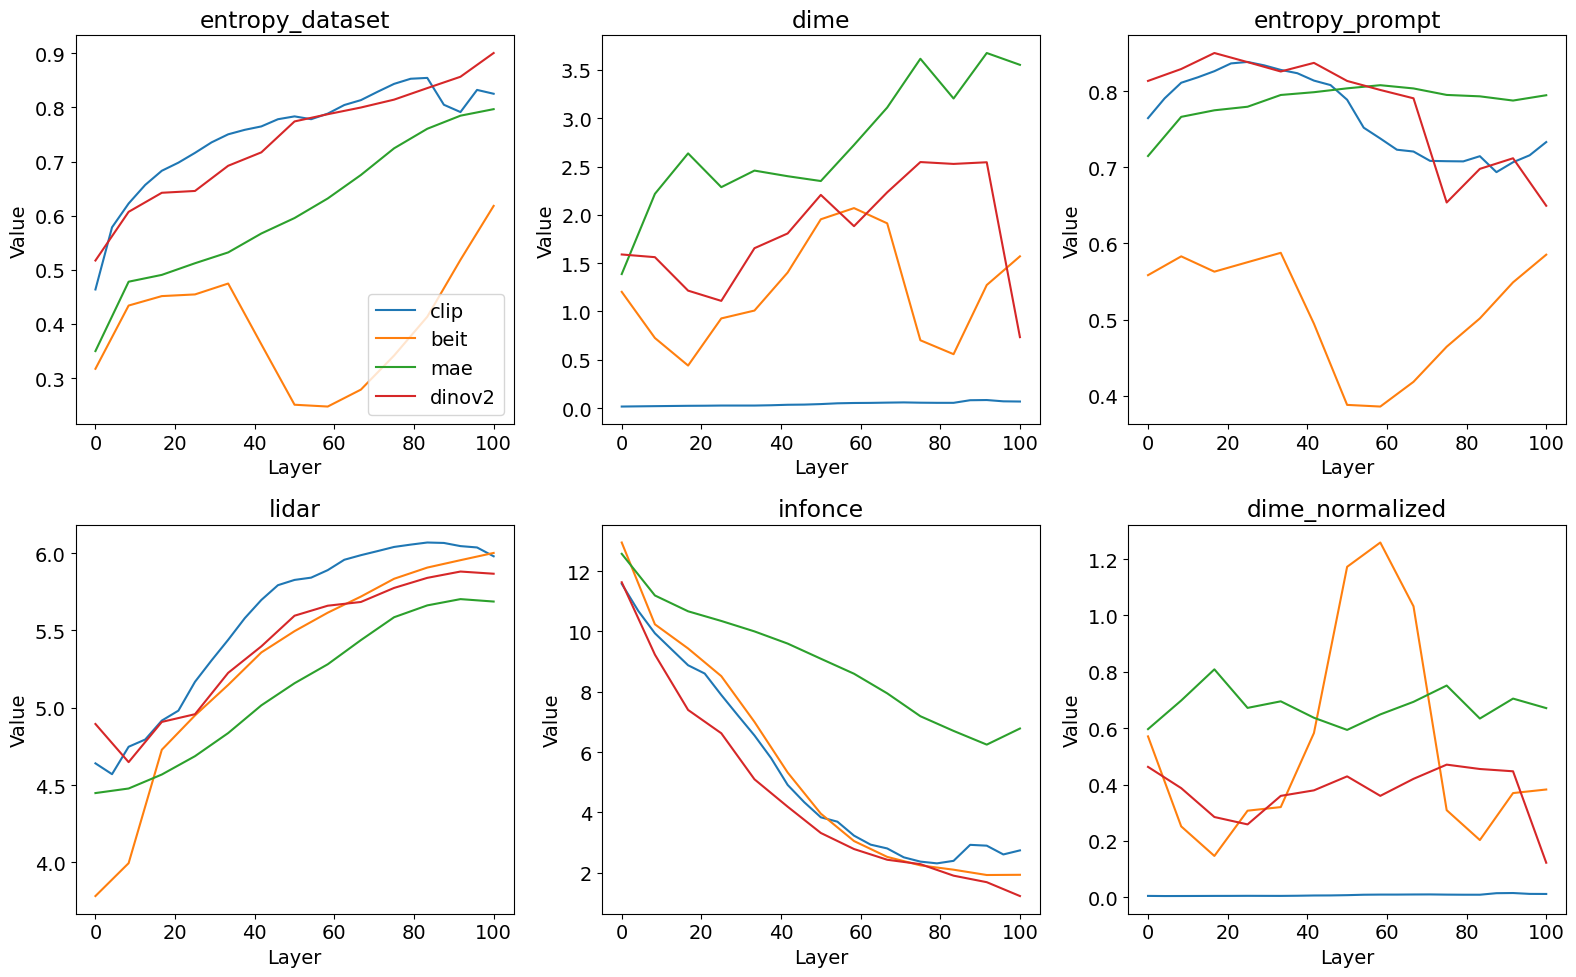

In [112]:
# make 6 subplots showing each metric across layers

plt.figure(figsize=(16, 10))
for model_name in IMAGE_MODEL_NAMES:
    for i, metric in enumerate(list(model_to_results[model_name].keys()) + ['dime_normalized']):
        plt.subplot(2, 3, i + 1)
        plt.title(metric)
        plt.xlabel('Layer')
        plt.ylabel('Value')

        print(i, metric, model_name)
        task_results = model_to_results[model_name]
        if metric == 'entropy_prompt':
            metric_values = task_results['entropy_prompt']['maxEntropy']
        elif metric == 'entropy_dataset':
            metric_values = task_results['entropy_dataset']['maxEntropy']
        elif metric == 'infonce':
            metric_values = task_results['infonce']['raw']
        elif metric == 'lidar':
            metric_values = task_results['lidar']['raw']
        elif metric == 'dime':
            metric_values = task_results['dime']['raw']
        elif metric == 'dime_normalized':
            metric_values = [task_results['dime']['raw'][idx] / task_results['entropy_dataset']['raw'][idx] for idx in range(len(task_results['dime']['raw']))]

        depth_percentages = np.linspace(0, 100, len(metric_values))
        plt.plot(depth_percentages, metric_values, label=model_name)

        if i == 0:
            plt.legend()
plt.tight_layout()
plt.show()

In [115]:
# put BERT and BeIT on the same plot

metrics = ['entropy_prompt', 'entropy_dataset', 'infonce', 'lidar', 'dime', 'dime_normalized']

# use the all_results to get BERT, and model_to_results to get BeIT
for metric in metrics:
    plt.figure(figsize=(6, 6))

    beit_metric_values = model_to_results['beit'][metric]
    bert_metric_values = all_results['bert']['base']['main']['layer_18'][metric]['average_main_score']
    plt.plot(model_to_results['beit'][metric], marker='o')
    plt.xlabel('BERT')
    plt.ylabel('BeIT')
    plt.title(metric)
    plt.show()

KeyError: 'entropy_prompt'

<Figure size 600x600 with 0 Axes>